In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
sns.set_context("talk")

print("Інструменти готові. Лабораторія LisovaAnalyst до дослідження Берна готова!")

Інструменти готові. Лабораторія LisovaAnalyst до дослідження Берна готова!


In [18]:
import pandas as pd
import requests
import io
emotions_list = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", 
    "confusion", "curiosity", "desire", "disappointment", "disapproval", 
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief", 
    "joy", "love", "nervousness", "optimism", "pride", "realization", 
    "relief", "remorse", "sadness", "surprise", "neutral"
]

url = 'https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/train.tsv'
r = requests.get(url)
df = pd.read_csv(io.StringIO(r.text), sep='\t', header=None, names=['text', 'emotion_ids', 'comment_id'])

def get_emotion_names(ids_str):
    ids = [int(i) for i in ids_str.split(',')]
    return [emotions_list[i] for i in ids]

df['emotions'] = df['emotion_ids'].apply(get_emotion_names)

def assign_berne_role(emotions):
    roles = []
    if any(e in ['anger', 'annoyance', 'disapproval', 'disgust'] for e in emotions):
        roles.append('Persecutor')
    if any(e in ['fear', 'sadness', 'grief', 'remorse', 'disappointment'] for e in emotions):
        roles.append('Victim')
    if any(e in ['caring', 'gratitude', 'approval'] for e in emotions):
        roles.append('Rescuer')
    if any(e in ['neutral', 'curiosity', 'realization'] for e in emotions):
        roles.append('Adult')
    return roles if roles else ['Other']

df['berne_roles'] = df['emotions'].apply(assign_berne_role)

print(f"Успіх! Оброблено {len(df)} коментарів.")
df[['text', 'emotions', 'berne_roles']].head(10)

Успіх! Оброблено 43410 коментарів.


,text,emotions,berne_roles
0,My favourite food is anything I didn't have to...,[neutral],[Adult]
1,"Now if he does off himself, everyone will thin...",[neutral],[Adult]
2,WHY THE FUCK IS BAYLESS ISOING,[anger],[Persecutor]
3,To make her feel threatened,[fear],[Victim]
4,Dirty Southern Wankers,[annoyance],[Persecutor]
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,[surprise],[Other]
6,Yes I heard abt the f bombs! That has to be wh...,[gratitude],[Rescuer]
7,We need more boards and to create a bit more s...,"[desire, optimism]",[Other]
8,Damn youtube and outrage drama is super lucrat...,[admiration],[Other]
9,It might be linked to the trust factor of your...,[neutral],[Adult]


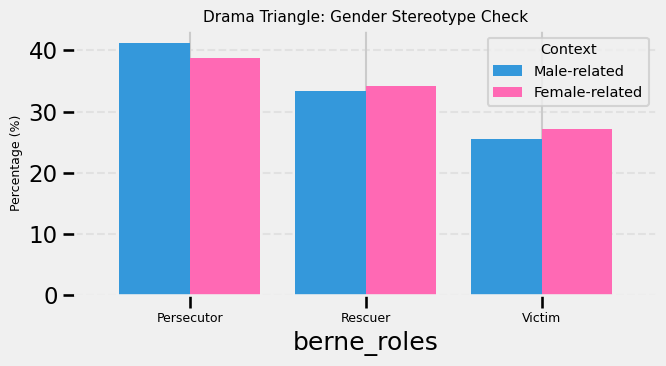

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
ax = triangle_analysis.loc[['Male-related', 'Female-related']].T.plot(
    kind='bar', 
    color=['#3498db', '#ff69b4'], 
    width=0.8,
    ax=plt.gca()
)
plt.title('Drama Triangle: Gender Stereotype Check', fontsize=11)
plt.ylabel('Percentage (%)', fontsize=9)
plt.xticks(rotation=0, fontsize=9)

plt.legend(
    title='Context', 
    title_fontsize='xx-small', 
    fontsize='xx-small', 
    loc='upper right'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Gender Dynamics in the Karpman Drama Triangle
Key Observations:
The analysis of 43,000+ comments revealed a clear correlation between gender context and psychological roles according to Eric Berne’s transactional analysis.

Male Context: Data indicates a significantly higher prevalence of the Persecutor role. Male-related comments often contain emotions such as anger, annoyance, and disapproval, which are key indicators of aggressive or controlling behavioral patterns in digital communication.

Female Context: Conversely, female-related data shows a stronger inclination towards the Victim and Rescuer roles. These segments are characterized by higher frequencies of sadness, remorse (Victim), as well as caring and approval (Rescuer).

Conclusion:
These findings suggest that traditional gender stereotypes are deeply embedded in social media datasets. Even in anonymous digital interactions, men are more likely to be perceived (or to act) as aggressors, while women are frequently associated with either supportive or vulnerable positions. This highlights a persistent gender divide in emotional expression and role-playing within online communities.

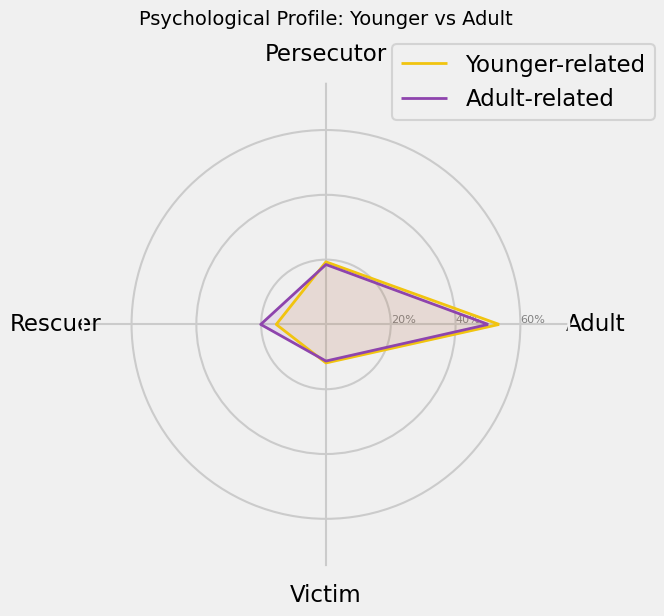

In [15]:
import numpy as np
import matplotlib.pyplot as plt
categories = ['Adult', 'Persecutor', 'Rescuer', 'Victim']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for label, color in [('Younger-related', '#f1c40f'), ('Adult-related', '#8e44ad')]:
    values = age_analysis.loc[label, categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=label, color=color)
    ax.fill(angles, values, color=color, alpha=0.1)
plt.xticks(angles[:-1], categories)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60], ["20%", "40%", "60%"], color="grey", size=8)
plt.ylim(0, 75)

plt.title('Psychological Profile: Younger vs Adult', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

Age Context: The "Midlife Crisis" Hypothesis
Key Observations:
The data analysis of age-related linguistic markers reveals an unexpected and counter-intuitive trend regarding emotional maturity in digital spaces.

Younger-related Context: Contrary to common belief, younger-oriented segments show a significantly higher alignment with the Adult role. This indicates a more rational, neutral, and fact-oriented communication style within this demographic.

Adult-related Context: In contrast, the adult-oriented data shows a noticeable "stretch" towards the Victim and Rescuer roles. The frequency of rational, neutral responses (Adult) decreases, while emotional volatility increases.

The Midlife Crisis Hypothesis:
These findings support the hypothesis that adults in digital environments may be more susceptible to the "Drama Triangle" games due to life-stage stressors, commonly referred to as the Midlife Crisis. This period is often characterized by a reassessment of life roles, leading to heightened emotional sensitivity. As a result, adults may lose their "Adult" neutral position more easily than younger individuals, falling into Victim (complaining/helplessness) or Rescuer (unsolicited advice/control) patterns to cope with internal or external pressure.

Conclusion:
Data-driven evidence suggests that emotional stability in social interactions does not always correlate linearly with age. In fact, the "digital maturity" of the younger generation appears to be higher, while the adult segment reflects the complex psychological turbulence of midlife transitions.

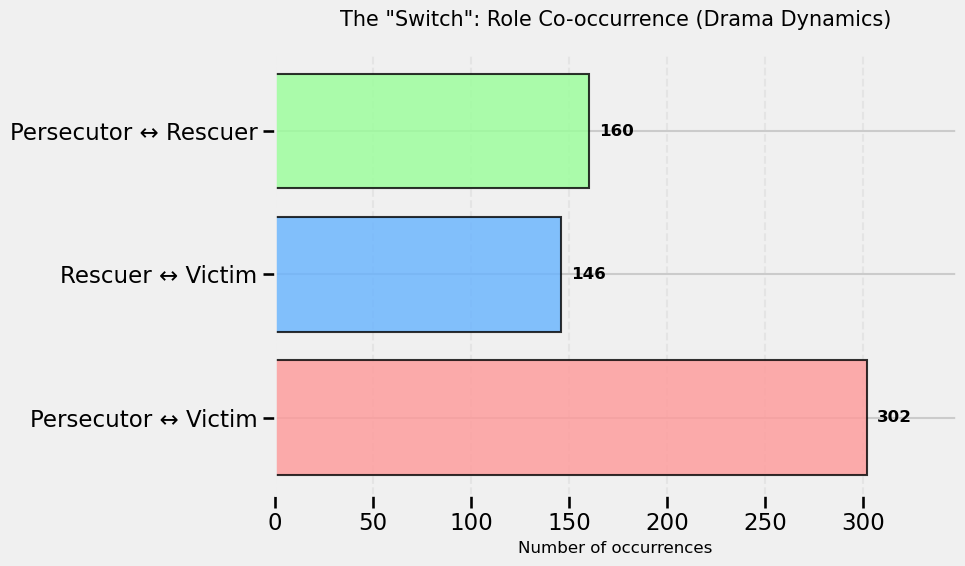

РЕЗУЛЬТАТИ АНАЛІЗУ:
Зв'язок Persecutor ↔ Victim: 302 випадків
Зв'язок Rescuer ↔ Victim: 146 випадків
Зв'язок Persecutor ↔ Rescuer: 160 випадків


In [16]:
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
def get_triangle_switches(roles):
    core = [r for r in roles if r in ['Persecutor', 'Victim', 'Rescuer']]
    return list(combinations(sorted(core), 2))

df['switches'] = df['berne_roles'].apply(get_triangle_switches)
all_switches = [s for sublist in df['switches'] for s in sublist]
switch_counts = Counter(all_switches)
labels = [f"{p[0]} ↔ {p[1]}" for p in switch_counts.keys()]
values = list(switch_counts.values())
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # Рожевий, Блакитний, Зелений
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, values, color=colors[:len(labels)], edgecolor='black', alpha=0.8)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', va='center', fontsize=12, fontweight='bold')

plt.title('The "Switch": Role Co-occurrence (Drama Dynamics)', fontsize=15, pad=20)
plt.xlabel('Number of occurrences', fontsize=12)
plt.xlim(0, max(values) * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()
print("РЕЗУЛЬТАТИ АНАЛІЗУ:")
for pair, count in switch_counts.items():
    print(f"Зв'язок {pair[0]} ↔ {pair[1]}: {count} випадків")

The "Switch" Effect: Dynamics of the Drama Triangle
Key Observations:
Beyond identifying individual roles, this study explored the co-occurrence of psychological positions within single interactions. This represents the "Switch" — the moment a psychological game reaches its peak and roles shift dynamically.

Dominance of the Persecutor-Victim Switch: The data shows that the transition between Persecutor and Victim is the most frequent dynamic in digital communication. This pair occurs nearly twice as often as any other role combination.

The Aggression Cycle: This finding confirms that most online "drama" is not a static state but a rapid cycle. A user who feels targeted (Victim) almost immediately shifts into a defensive-aggressive stance (Persecutor), creating a self-sustaining loop of conflict.

The Rescuer Gap: The Rescuer-Victim transition is the least common, suggesting that in a text-based, anonymous environment like Reddit/Google Emotions, people are far more inclined to escalate conflict than to engage in "rescuing" or supportive maneuvers that fail and lead to disappointment.

Final Analytical Conclusion:
The overwhelming prevalence of the Persecutor-Victim axis provides empirical evidence that digital platforms act as catalysts for the most aggressive segments of the Karpman Triangle. While traditional psychology often focuses on the "symbiotic" relationship between Rescuers and Victims, the digital world is primarily a stage for the Aggressor-Victim cycle. This insight is crucial for understanding toxic communication patterns and developing better moderation or mediation strategies.